# Proyecto de Vision por Computador Semana 1

## GRUPO 6 - PARALELO B
- CHILUISA GALLARDO ROBINSON
- LANCHIMBA CAIZA NATALY FERNANDA
- CHOEZ ARTEAGA TEOFILO MANUEL

# Parte 1
- Cargar una imagen con OpenCV
- Mostrar la imagen cargada
- Convertirla a escala de grises
- Aplicar el filtro de deteccion de bordes Canny
- Mostrar la imagen procesada
- Buscar otro filtro diferente a Canny
- Aplicar el filtro a la imagen original y a la procesada con el filtro Canny
- Mostrar los resultados de las 2 imagenes procesadas con el nuevo filtro
- Escribir sobre las diferencias de los resultados de las dos imagenes

En este primer bloque importamos las librerias que usaremos durante todo el ejercicio: OpenCV para procesar imagenes, NumPy para operaciones numericas y Matplotlib para visualizar los resultados.

### Paso previo: instalacion de librerias (solo si faltan)
Este bloque verifica si las librerias necesarias estan instaladas. Si alguna no existe, se instala automaticamente con `pip`.

In [57]:
import importlib
import subprocess
import sys

paquetes = {
    "cv2": "opencv-python",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
}

faltantes = []
for modulo, paquete in paquetes.items():
    try:
        importlib.import_module(modulo)
    except ImportError:
        faltantes.append(paquete)

if faltantes:
    print(f"Instalando paquetes faltantes: {faltantes}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *faltantes])
else:
    print("Todas las librerias requeridas ya estan instaladas.")

Todas las librerias requeridas ya estan instaladas.


In [58]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import LinearSVC

Cargamos la imagen original desde una ruta local y la mostramos para confirmar que se leyo correctamente antes de aplicar cualquier transformacion.

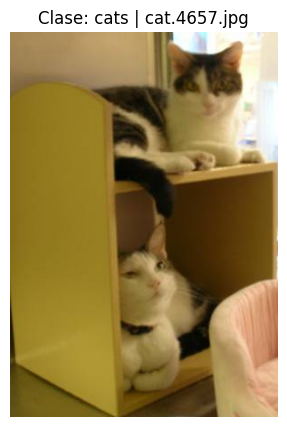

In [59]:
ruta_cats_train = Path(r'..\Grupales\dataset\train\cats')
imagenes = [p for p in ruta_cats_train.iterdir() if p.is_file()]

if len(imagenes) == 0:
    raise ValueError(f'No hay imagenes en: {ruta_cats_train}')

ruta_img = random.choice(imagenes)
img = cv2.imread(str(ruta_img))

if img is None:
    raise ValueError(f'No se pudo leer la imagen: {ruta_img}')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Visualizar imagen
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title(f'Clase: cats | {ruta_img.name}')
plt.axis('off')
plt.show()

En este paso convertimos la imagen a escala de grises para simplificar la informacion visual y facilitar la deteccion de bordes en los siguientes filtros.

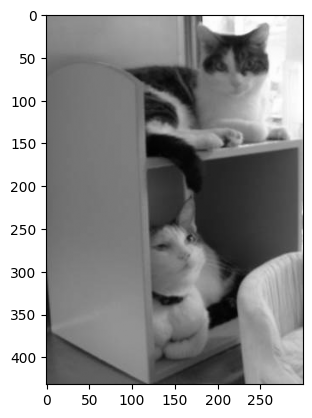

In [60]:
## Convertir la imagen a escala de grises

imggris=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

plt.imshow(imggris,cmap='gray')
plt.show()

Ahora aplicamos Canny para detectar bordes y luego Sobel, tanto sobre la imagen original como sobre la salida de Canny, para comparar como cambia el realce de contornos.

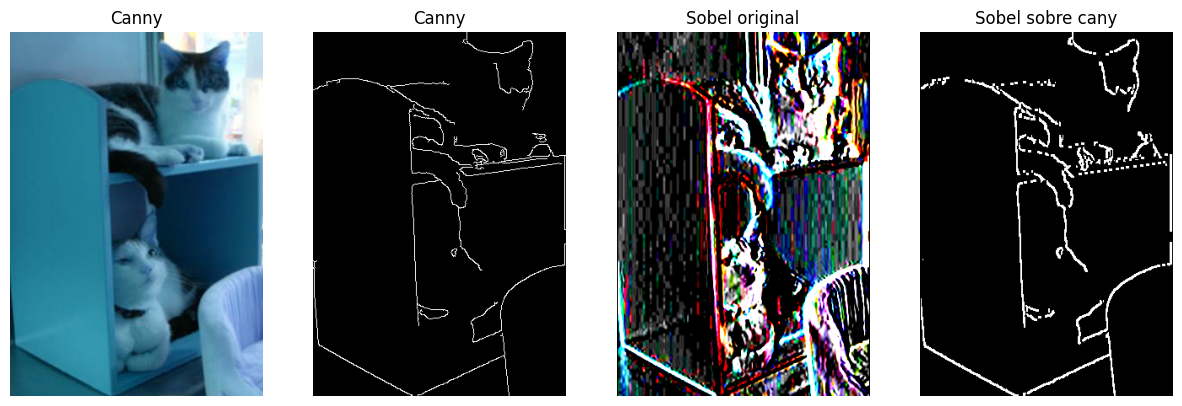

In [61]:
## Aplicar filtro cany

imgcany=cv2.Canny(img,5,300)

## Aplicar filtro sobel a la imagen original
imgsobel=cv2.Sobel(img,cv2.CV_8U,1,0,ksize=5)

## Aplicar filtro sobel a la imagen cany
imgsobel2=cv2.Sobel(imgcany,cv2.CV_8U,1,0,ksize=5)

plt.figure(figsize=(15,5))
plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(imgcany, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(imgsobel, cmap='gray')
plt.title('Sobel original')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(imgsobel2, cmap='gray')
plt.title('Sobel sobre cany')
plt.axis('off')

plt.show()

Al combinar los filtros cany y sobel se puede ver que los bordes identificados con cany se hacen más notorios o más acentuados algo que mejora la identificación de bordes mientras que al aplicar sobel sobre la imagen orginal se mantiene mejor la figura en la imagen ya que como se ve no se pierde la imagen del gatito. Adicionalmente, se evidencio que al disminuir el primer umbral de Cany se detectan más bordes que al incrementar este parámetro.

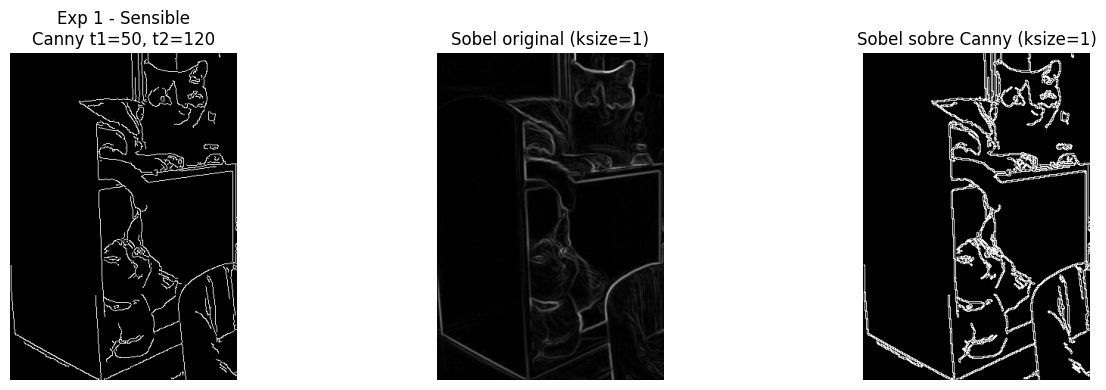

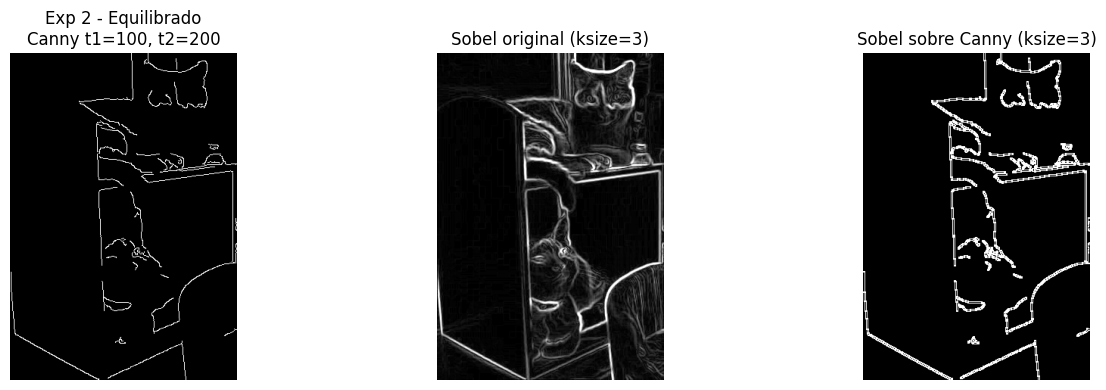

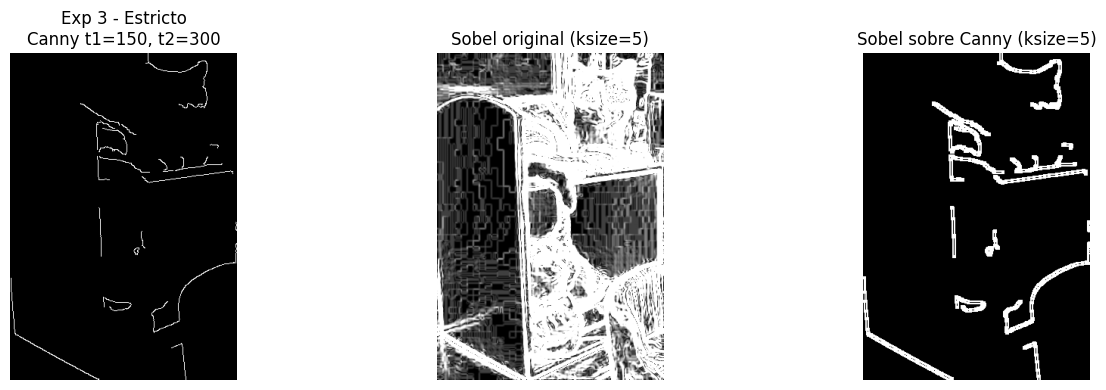

In [62]:
## Aplicar filtro cany

experimentos = [
    {"nombre": "Exp 1 - Sensible", "t1": 50, "t2": 120, "ksize": 1},
    {"nombre": "Exp 2 - Equilibrado", "t1": 100, "t2": 200, "ksize": 3},
    {"nombre": "Exp 3 - Estricto", "t1": 150, "t2": 300, "ksize": 5},
]

for exp in experimentos:
    canny = cv2.Canny(imggris, exp["t1"], exp["t2"])

    sobel_x_o = cv2.Sobel(imggris, cv2.CV_64F, 1, 0, ksize=exp["ksize"])
    sobel_y_o = cv2.Sobel(imggris, cv2.CV_64F, 0, 1, ksize=exp["ksize"])
    sobel_original = cv2.convertScaleAbs(cv2.magnitude(sobel_x_o, sobel_y_o))

    sobel_x_c = cv2.Sobel(canny, cv2.CV_64F, 1, 0, ksize=exp["ksize"])
    sobel_y_c = cv2.Sobel(canny, cv2.CV_64F, 0, 1, ksize=exp["ksize"])
    sobel_canny = cv2.convertScaleAbs(cv2.magnitude(sobel_x_c, sobel_y_c))

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(canny, cmap="gray")
    plt.title(f"{exp['nombre']}\nCanny t1={exp['t1']}, t2={exp['t2']}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(sobel_original, cmap="gray")
    plt.title(f"Sobel original (ksize={exp['ksize']})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(sobel_canny, cmap="gray")
    plt.title(f"Sobel sobre Canny (ksize={exp['ksize']})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()





# Parte 2
- Importar la base de datos y visualizar 5 ejemplos por cada clase
- Dividir la base de datos en entrenamiento, validacion y prueba
- Extraer caracteristicas de las imagenes
- Crear un clasificador en base a las caracteristicas extraidas
- Evaluar el clasificador y reportar exactitud (objetivo >= 70%)

En esta parte importamos herramientas para manejar rutas y aleatoriedad, y tambien los metodos de scikit-learn que usaremos para entrenar y evaluar el clasificador.

In [63]:
RUTA_DATASET = (Path.cwd() / r'..\Grupales\dataset').resolve()
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f'Ruta dataset detectada: {RUTA_DATASET}')

if not RUTA_DATASET.exists():
    raise FileNotFoundError(
        f'No existe el dataset en: {RUTA_DATASET}. '
        'Verifica que la carpeta src/dataset este creada y que el notebook se ejecute desde src/code.'
    )

splits_requeridos = ['train', 'val', 'test']
clases_requeridas = ['cats', 'dogs']

for split in splits_requeridos:
    for clase in clases_requeridas:
        ruta_split_clase = RUTA_DATASET / split / clase
        if not ruta_split_clase.exists():
            raise FileNotFoundError(f'Falta carpeta requerida: {ruta_split_clase}')

Ruta dataset detectada: C:\Users\ASUS VIVOBOOK PRO\Desktop\Nataly\Maestria\Vision por computador\Grupales\dataset


Con este bloque mostramos ejemplos reales del conjunto de entrenamiento para verificar visualmente que las clases estan bien organizadas y que las imagenes se leen sin problemas.

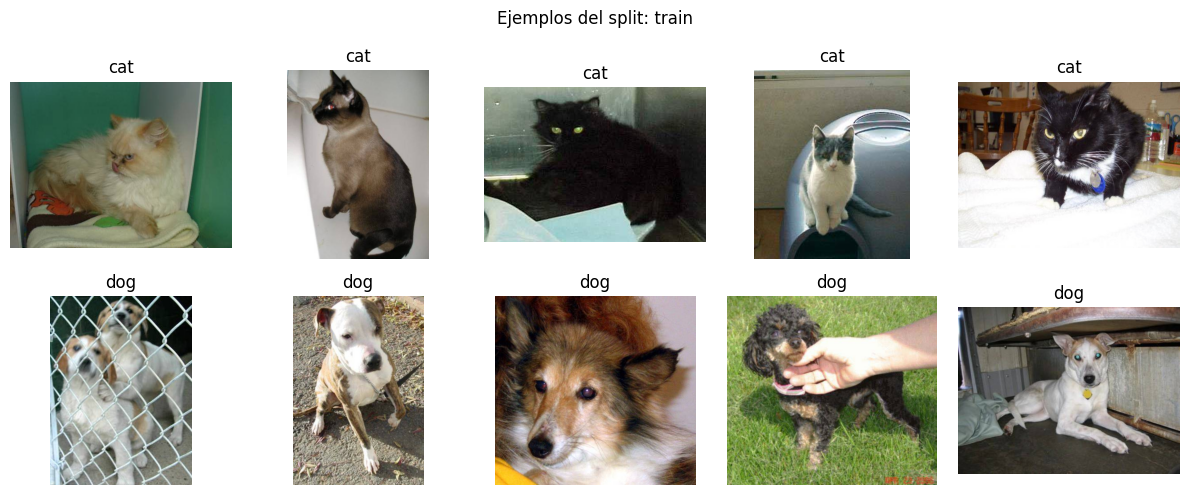

In [64]:
def mostrar_ejemplos_por_clase(ruta_base, split='train', n=5):
    clases = ['cats', 'dogs']
    plt.figure(figsize=(12, 5))

    for i, clase in enumerate(clases):
        ruta_clase = Path(ruta_base) / split / clase
        imagenes = [p for p in ruta_clase.iterdir() if p.is_file()]
        random.shuffle(imagenes)
        seleccion = imagenes[:n]

        for j, ruta_img in enumerate(seleccion):
            img_bgr = cv2.imread(str(ruta_img))
            if img_bgr is None:
                continue
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            pos = i * n + j + 1
            plt.subplot(2, n, pos)
            plt.imshow(img_rgb)
            plt.title(clase[:-1])
            plt.axis('off')

    plt.suptitle(f'Ejemplos del split: {split}')
    plt.tight_layout()
    plt.show()


mostrar_ejemplos_por_clase(RUTA_DATASET, split='train', n=5)

Aqui definimos como convertir cada imagen en un vector de caracteristicas usando HOG. Luego cargamos train, validacion y prueba para tener los datos listos para el modelo.

In [71]:
def extraer_hog_cv2(img_bgr):
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.equalizeHist(img_gray) # Ecualizar la imagen para identificar mejor las características
    img_resize = cv2.resize(img_gray, (64, 64))

    hog = cv2.HOGDescriptor(
        _winSize=(64, 64),
        _blockSize=(16, 16),
        _blockStride=(8, 8),
        _cellSize=(8, 8),
        _nbins=9,
    )
    caracteristicas = hog.compute(img_resize)
    return caracteristicas.flatten()


def cargar_split(ruta_base, split):
    X, y = [], []
    clases = ['cats', 'dogs']

    for etiqueta, clase in enumerate(clases):
        ruta_clase = Path(ruta_base) / split / clase
        for ruta_img in ruta_clase.iterdir():
            if not ruta_img.is_file():
                continue

            img_bgr = cv2.imread(str(ruta_img))
            if img_bgr is None:
                continue

            feat = extraer_hog_cv2(img_bgr)
            X.append(feat)
            y.append(etiqueta)

    return np.array(X), np.array(y)


X_train, y_train = cargar_split(RUTA_DATASET, 'train')
X_val, y_val = cargar_split(RUTA_DATASET, 'val')
X_test, y_test = cargar_split(RUTA_DATASET, 'test')

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (1416, 1764) (1416,)
Val  : (304, 1764) (304,)
Test : (303, 1764) (303,)


Finalmente entrenamos un clasificador lineal, calculamos la exactitud en validacion y prueba, y visualizamos la matriz de confusion para entender mejor los aciertos y errores por clase.

In [72]:
# valores de C que vamos a probar
valores_C = [0.001, 0.01, 0.1, 1, 10]

mejor_C = None
mejor_accuracy = 0

for c in valores_C:
    
    modelo = LinearSVC(C=c, max_iter=5000, random_state=SEED)
    modelo.fit(X_train, y_train)
    
    pred_val = modelo.predict(X_val)
    acc = accuracy_score(y_val, pred_val)
    
    print(f"C = {c}  ->  Accuracy = {acc:.4f}")
    
    if acc > mejor_accuracy:
        mejor_accuracy = acc
        mejor_C = c

print("\nMejor C encontrado:", mejor_C)
print("Accuracy en validación:", mejor_accuracy)

C = 0.001  ->  Accuracy = 0.7467
C = 0.01  ->  Accuracy = 0.7401
C = 0.1  ->  Accuracy = 0.6908
C = 1  ->  Accuracy = 0.6250
C = 10  ->  Accuracy = 0.6151

Mejor C encontrado: 0.001
Accuracy en validación: 0.7467105263157895


c:\Users\ASUS VIVOBOOK PRO\anaconda3\envs\Naty\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy validacion: 0.7467
Accuracy prueba    : 0.7063

Reporte de clasificacion (test):
              precision    recall  f1-score   support

        cats       0.73      0.66      0.69       152
        dogs       0.69      0.75      0.72       151

    accuracy                           0.71       303
   macro avg       0.71      0.71      0.71       303
weighted avg       0.71      0.71      0.71       303



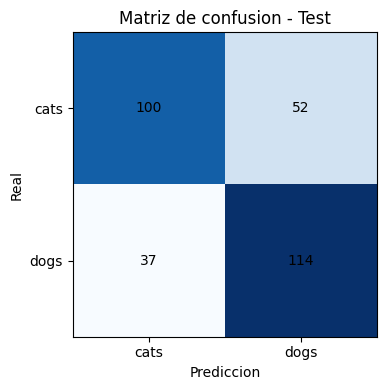

In [73]:
clasificador = LinearSVC(random_state=SEED, max_iter=5000, C=0.001)
clasificador.fit(X_train, y_train)

pred_val = clasificador.predict(X_val)
pred_test = clasificador.predict(X_test)

acc_val = accuracy_score(y_val, pred_val)
acc_test = accuracy_score(y_test, pred_test)

print(f'Accuracy validacion: {acc_val:.4f}')
print(f'Accuracy prueba    : {acc_test:.4f}')
print('\nReporte de clasificacion (test):')
print(classification_report(y_test, pred_test, target_names=['cats', 'dogs']))

cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Matriz de confusion - Test')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.xticks([0, 1], ['cats', 'dogs'])
plt.yticks([0, 1], ['cats', 'dogs'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

In [74]:
print(f'Accuracy validacion: {acc_val:.4f}')
print(f'Accuracy prueba: {acc_test:.4f}')
print('Matriz de confusion:')
print(cm)

Accuracy validacion: 0.7467
Accuracy prueba: 0.7063
Matriz de confusion:
[[100  52]
 [ 37 114]]
